# 04 — Semi-supervised: Pseudo-labeling (E4)

Pseudo-labeling pipeline:
1. Train M₀ on labeled subset (ISIC 2018, fraction X%)
2. Generate confident pseudo-labels on ISIC 2020 train (threshold=0.9)
3. Merge labeled + pseudo-labeled → retrain

Evaluate on source test (ISIC 2018) + target test (ISIC 2020).
Compare AUC vs Label Budget against E2 baseline and E3 SSL.

In [11]:
import os, sys, copy, json, torch, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import (
    evaluate_and_report, evaluate_on_csv, get_latest_run,
    collect_predictions, plot_training_history, collect_auc_vs_fraction, NumpyEncoder,
)
from src.trainers.supervised import run_experiment
from src.pseudo_labeling import (
    build_unlabeled_loader, generate_pseudo_labels,
    save_pseudo_label_csv, make_merged_csv,
)
from src.utils import get_device, load_config, init_run_dir, cleanup
from src.metrics import compute_metrics, plot_auc_vs_labels, plot_confusion_matrix, plot_roc_curve
from data.scripts.make_label_subsets import FRACTIONS

ALL_FRACTIONS = FRACTIONS + [1.0]
print('ALL_FRACTIONS:', ALL_FRACTIONS)

ALL_FRACTIONS: [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [12]:
config = load_config('configs/pseudo_label.yaml')
config

{'experiment': {'name': 'pseudo_label_resnet18', 'seed': 42, 'device': 'auto'},
 'data': {'task': 'supervised',
  'train_csv': 'data/processed/isic2018/train.csv',
  'val_csv': 'data/processed/isic2018/val.csv',
  'test_csv': 'data/processed/isic2018/test.csv',
  'img_size': 224,
  'batch_size': 64,
  'num_workers': 4,
  'use_weighted_sampler': True,
  'label_col': 'target'},
 'model': {'arch': 'resnet18', 'pretrained': True, 'num_classes': 1},
 'training': {'epochs': 50,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs': 5},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'early_stopping': {'patience': 10, 'monitor': 'val_auc'},
 'pseudo_label': {'threshold': 0.9,
  'min_pseudo_samples': 10,
  'unlabeled_csv': 'data/processed/isic2020/train.csv',
  'freeze_backbone_epochs_low': 5,
  'freeze_backbone_epochs_high': 0,
  'm0_patience': 10},
 'logging': {'save_dir': 'results/runs', '

## 1. Pseudo-labelling cycle

For each fraction:
1. Train M₀ on a labelled subset (train M₀)
2. Load the best checkpoint of M₀
3. Generate pseudo-labels on the ISIC 2020 training set (confidence >= threshold)
4. Combine labelled + pseudo-labelled → merged CSV
5. Retrain on the merged data

The cycle saves intermediate M₀ runs as `pseudo_label_m0_{fraction}` and final runs as `pseudo_label_ft_{fraction}`.
Skip if final run + test_metrics.json exist and `RUN_PSEUDO=False`.

In [ ]:
RUN_PSEUDO = False  # True to force regeneration even if it already exists

device = get_device(config['experiment'].get('device', 'auto'))
print(f'Device: {device}')

pl_cfg = config['pseudo_label']
THRESHOLD = pl_cfg['threshold']
MIN_PSEUDO = pl_cfg.get('min_pseudo_samples', 10)
UNLABELED_CSV = pl_cfg['unlabeled_csv']
M0_PATIENCE = pl_cfg.get('m0_patience', config['early_stopping']['patience'])
TMP_DIR = Path('results/runs/_pseudo_intermediate')
TMP_DIR.mkdir(parents=True, exist_ok=True)

for fraction in ALL_FRACTIONS:
    exp_name_ft = f'pseudo_label_ft_{fraction:.2f}'
    run_dir_ft = get_latest_run(exp_name_ft)
    ft_complete = run_dir_ft is not None and (run_dir_ft / 'checkpoints/best.pt').exists()

    if ft_complete and not RUN_PSEUDO:
        frac_tmp = TMP_DIR / f'{fraction:.2f}'
        for _f in ['pseudo_labels.csv', 'merged_train.csv']:
            src = frac_tmp / _f
            dst = run_dir_ft / _f
            if src.exists() and not dst.exists():
                import shutil
                shutil.copy2(src, dst)
                print(f'  [SYNC] copied {_f} to run dir')
        print(f'[SKIP] {exp_name_ft} — run already complete')
        cleanup()
        continue

    frac_tmp = TMP_DIR / f'{fraction:.2f}'
    frac_tmp.mkdir(parents=True, exist_ok=True)
    pseudo_csv_path = frac_tmp / 'pseudo_labels.csv'
    merged_csv_path = frac_tmp / 'merged_train.csv'

    # ── 1. Train M₀ on labeled subset ──────────────────────────────────
    exp_name_m0 = f'pseudo_label_m0_{fraction:.2f}'
    run_dir_m0 = get_latest_run(exp_name_m0)
    has_m0_ckpt = run_dir_m0 is not None and (run_dir_m0 / 'checkpoints/best.pt').exists()

    if not has_m0_ckpt or RUN_PSEUDO:
        print(f"\n{'='*55}")
        print(f'M₀ training | fraction={fraction:.2f}')
        print(f"{'='*55}")
        m0_cfg = copy.deepcopy(config)
        if fraction >= 1.0:
            m0_cfg['data']['train_csv'] = 'data/processed/isic2018/train.csv'
        else:
            pct = int(round(fraction * 100))
            m0_cfg['data']['train_csv'] = f'data/processed/isic2018/subsets/train_{pct:02d}pct.csv'
        m0_cfg['data']['val_csv'] = 'data/processed/isic2018/val.csv'
        m0_cfg['data']['use_weighted_sampler'] = True
        m0_cfg['experiment']['name'] = exp_name_m0
        m0_freeze = pl_cfg.get('freeze_backbone_epochs_low', 5) if fraction <= 0.05 else pl_cfg.get('freeze_backbone_epochs_high', 0)
        m0_cfg['training']['freeze_backbone_epochs'] = m0_freeze
        m0_cfg['early_stopping']['patience'] = max(M0_PATIENCE, m0_freeze + 5)

        result_m0 = run_experiment(m0_cfg)
        run_dir_m0 = Path(result_m0['run_dir'])
        print(f'[OK M₀] best_val_auc={result_m0["best_val_auc"]:.4f}')
        del result_m0, m0_cfg
        cleanup()
    else:
        print(f'[CACHE M₀] {exp_name_m0} — checkpoint already present')
        run_dir_m0 = get_latest_run(exp_name_m0)

    # ── 2. Generate pseudo-labels on ISIC 2020 train ───────────────────
    if not pseudo_csv_path.exists() or RUN_PSEUDO:
        print(f'  Generating pseudo-labels (threshold={THRESHOLD})...')
        m0_ckpt_path = run_dir_m0 / 'checkpoints/best.pt'
        model_m0 = build_backbone(
            arch=config['model']['arch'],
            pretrained=False,
            num_classes=config['model'].get('num_classes', 1),
        )
        ckpt = torch.load(m0_ckpt_path, map_location=device)
        model_m0.load_state_dict(ckpt['model'])
        model_m0.to(device)

        unlabeled_loader = build_unlabeled_loader(
            UNLABELED_CSV,
            batch_size=config['data'].get('batch_size', 64),
            num_workers=config['data'].get('num_workers', 4),
            img_size=config['data'].get('img_size', 224),
        )
        pseudo_df = generate_pseudo_labels(
            model_m0, unlabeled_loader, device,
            threshold=THRESHOLD,
        )

        del model_m0, ckpt, unlabeled_loader
        cleanup()

        if len(pseudo_df) < MIN_PSEUDO:
            print(f'  ⚠ WARNING: {len(pseudo_df)} pseudo-labels < min_pseudo_samples={MIN_PSEUDO}')
            print(f'  Skipping retrain — insufficient confident samples.')
            pseudo_df.to_csv(pseudo_csv_path, index=False)
            (frac_tmp / '.skip').touch()
            continue
        else:
            save_pseudo_label_csv(pseudo_df, pseudo_csv_path)
            (frac_tmp / '.skip').unlink(missing_ok=True)

    elif (frac_tmp / '.skip').exists():
        print(f'[SKIP] {exp_name_ft} — insufficient pseudo-labels (marked .skip)')
        cleanup()
        continue
    else:
        pseudo_df = pd.read_csv(pseudo_csv_path)
        print(f'  [CACHE] {len(pseudo_df)} pseudo-labels loaded')

    # ── 3. Merge labeled + pseudo-labeled ──────────────────────────────
    if fraction >= 1.0:
        labeled_csv = 'data/processed/isic2018/train.csv'
    else:
        pct = int(round(fraction * 100))
        labeled_csv = f'data/processed/isic2018/subsets/train_{pct:02d}pct.csv'

    if not merged_csv_path.exists() or RUN_PSEUDO:
        make_merged_csv(labeled_csv, pseudo_csv_path, merged_csv_path)
    else:
        print(f'  [CACHE] merged CSV')

    # ── 4. Retrain on merged data ──────────────────────────────────────
    print(f"\n  Retrain on merged | fraction={fraction:.2f}")
    retrain_cfg = copy.deepcopy(config)
    retrain_cfg['data']['train_csv'] = str(merged_csv_path)
    retrain_cfg['data']['val_csv'] = 'data/processed/isic2018/val.csv'
    retrain_cfg['data']['use_weighted_sampler'] = True
    retrain_cfg['experiment']['name'] = exp_name_ft
    if fraction <= 0.05:
        retrain_cfg['training']['freeze_backbone_epochs'] = pl_cfg.get('freeze_backbone_epochs_low', 5)
    else:
        retrain_cfg['training']['freeze_backbone_epochs'] = pl_cfg.get('freeze_backbone_epochs_high', 0)
    # Retrain uses patience from YAML config (early_stopping.patience: 10)
    retrain_cfg['early_stopping']['patience'] = config['early_stopping']['patience']

    result_ft = run_experiment(retrain_cfg)
    ft_run_dir = Path(result_ft['run_dir'])

    # Copy intermediate artifacts into the final run dir for record-keeping
    import shutil
    if pseudo_csv_path.exists() and not (ft_run_dir / 'pseudo_labels.csv').exists():
        shutil.copy2(pseudo_csv_path, ft_run_dir / 'pseudo_labels.csv')
    if merged_csv_path.exists() and not (ft_run_dir / 'merged_train.csv').exists():
        shutil.copy2(merged_csv_path, ft_run_dir / 'merged_train.csv')

    print(f'[OK FT] {exp_name_ft} | best_val_auc={result_ft["best_val_auc"]:.4f}')

    # Free memory before next fraction
    del result_ft, ft_run_dir, retrain_cfg, pseudo_df
    cleanup()

print('\nPseudo-labeling loop complete.')

Device: mps
[CACHE M₀] pseudo_label_m0_0.01 — checkpoint gia presente
[SKIP] pseudo_label_ft_0.01 — insufficient pseudo-labels (marked .skip)
[CACHE M₀] pseudo_label_m0_0.05 — checkpoint gia presente
[SKIP] pseudo_label_ft_0.05 — insufficient pseudo-labels (marked .skip)
[SKIP] pseudo_label_ft_0.10 — run gia completa
[SKIP] pseudo_label_ft_0.25 — run gia completa
[SKIP] pseudo_label_ft_0.50 — run gia completa
[SKIP] pseudo_label_ft_1.00 — run gia completa

Pseudo-labeling loop completato.


## 2. Evaluation on source (ISIC 2018) and target (ISIC 2020)

Load `best.pt` from each pseudo-labelled run, evaluate on both test sets.
Save `test_metrics.json` (source) and `test_metrics_isic2020.json` (target).
Skip if files already exist and `RUN_EVAL=False`.

In [ ]:
RUN_EVAL = False

device = get_device(config['experiment'].get('device', 'auto'))

for fraction in ALL_FRACTIONS:
    exp_name = f'pseudo_label_ft_{fraction:.2f}'
    run_dir_ft = get_latest_run(exp_name)
    if run_dir_ft is None:
        print(f'[SKIP] {exp_name}: run not found')
        cleanup()
        continue
    ckpt_path = run_dir_ft / 'checkpoints/best.pt'
    if not ckpt_path.exists():
        print(f'[SKIP] {exp_name}: best.pt missing')
        cleanup()
        continue

    src_metrics_path = run_dir_ft / 'test_metrics.json'
    tgt_metrics_path = run_dir_ft / 'test_metrics_isic2020.json'
    both_exist = src_metrics_path.exists() and tgt_metrics_path.exists()
    if both_exist and not RUN_EVAL:
        src_auc = json.load(open(src_metrics_path)).get('auc_roc', '?')
        tgt_auc = json.load(open(tgt_metrics_path)).get('auc_roc', '?')
        print(f'[SKIP] {exp_name}: src={src_auc:.4f} tgt={tgt_auc:.4f} (cached)')
        cleanup()
        continue

    # Evaluate source
    src_auc = evaluate_on_csv(
        run_dir_ft, config,
        test_csv='data/processed/isic2018/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics.json',
    )
    src_val = src_auc.get('auc_roc') if src_auc else None

    # Evaluate target
    tgt_auc = evaluate_on_csv(
        run_dir_ft, config,
        test_csv='data/processed/isic2020/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics_isic2020.json',
    )
    tgt_val = tgt_auc.get('auc_roc') if tgt_auc else None

    print(f'[DONE] {exp_name}: src={src_val:.4f} tgt={tgt_val:.4f}')
    cleanup()

print('\nEvaluation complete.')

[SKIP] pseudo_label_ft_0.01: run non trovato
[SKIP] pseudo_label_ft_0.05: run non trovato
[SKIP] pseudo_label_ft_0.10: src=0.8660 tgt=0.6725 (cached)
[SKIP] pseudo_label_ft_0.25: src=0.8711 tgt=0.6255 (cached)
[SKIP] pseudo_label_ft_0.50: src=0.9063 tgt=0.6445 (cached)
[SKIP] pseudo_label_ft_1.00: src=0.9244 tgt=0.6473 (cached)

Valutazione completata.


## 3. Collect AUC — Baseline, SSL, Pseudo-label

In [15]:
def _read_auc(run_dir, filename):
    p = run_dir / filename
    if p.exists():
        return json.load(open(p)).get('auc_roc')
    return None

# ── Pseudo-label ─────────────────────────────────────────────────────────
aucs_2018_pseudo, aucs_2020_pseudo = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'pseudo_label_ft_{f:.2f}')
    aucs_2018_pseudo[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_pseudo[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Baseline (from E2 runs) ──────────────────────────────────────────────
aucs_2018_base, aucs_2020_base = {}, {}
for f in FRACTIONS:
    rd = get_latest_run(f'baseline_resnet18_{f:.2f}')
    aucs_2018_base[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_base[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None
rd_full = get_latest_run('baseline_resnet18_full')
aucs_2018_base[1.0] = _read_auc(rd_full, 'test_metrics.json') if rd_full else None
aucs_2020_base[1.0] = _read_auc(rd_full, 'test_metrics_isic2020.json') if rd_full else None

# ── SSL (from E3 runs) ───────────────────────────────────────────────────
aucs_2018_ssl, aucs_2020_ssl = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'simclr_ft_{f:.2f}')
    aucs_2018_ssl[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_ssl[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

print('Pseudo source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_pseudo.items() if v})
print('Pseudo target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_pseudo.items() if v})
print('Base  source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_base.items() if v})
print('Base  target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_base.items() if v})
print('SSL   source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_ssl.items() if v})
print('SSL   target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_ssl.items() if v})

Pseudo source: {'10%': 0.866, '25%': 0.8711, '50%': 0.9063, '100%': 0.9244}
Pseudo target: {'10%': 0.6725, '25%': 0.6255, '50%': 0.6445, '100%': 0.6473}
Base  source: {'1%': 0.8138, '5%': 0.8629, '10%': 0.8631, '25%': 0.8679, '50%': 0.9065, '100%': 0.9181}
Base  target: {'1%': 0.6619, '5%': 0.7118, '10%': 0.6853, '25%': 0.6294, '50%': 0.6353, '100%': 0.6975}
SSL   source: {'1%': 0.8451, '5%': 0.873, '10%': 0.8699, '25%': 0.8836, '50%': 0.909, '100%': 0.934}
SSL   target: {'1%': 0.7984, '5%': 0.6736, '10%': 0.6559, '25%': 0.6144, '50%': 0.6817, '100%': 0.6939}


## 4. Plot AUC vs Label Budget — Baseline vs SSL vs Pseudo-labeling

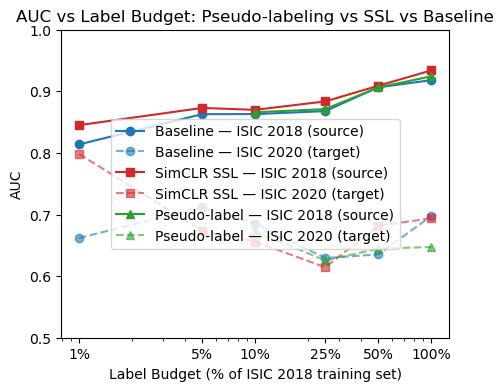

Figura salvata in results/figures/auc_vs_labels_pseudo.png


In [16]:
results = {
    'Baseline — ISIC 2018 (source)':     {f: v for f, v in aucs_2018_base.items() if v is not None},
    'Baseline — ISIC 2020 (target)':     {f: v for f, v in aucs_2020_base.items() if v is not None},
    'SimCLR SSL — ISIC 2018 (source)':   {f: v for f, v in aucs_2018_ssl.items() if v is not None},
    'SimCLR SSL — ISIC 2020 (target)':   {f: v for f, v in aucs_2020_ssl.items() if v is not None},
    'Pseudo-label — ISIC 2018 (source)': {f: v for f, v in aucs_2018_pseudo.items() if v is not None},
    'Pseudo-label — ISIC 2020 (target)': {f: v for f, v in aucs_2020_pseudo.items() if v is not None},
}
style_map = {
    'Baseline — ISIC 2018 (source)':     {'color': 'tab:blue',   'linestyle': '-',  'marker': 'o'},
    'Baseline — ISIC 2020 (target)':     {'color': 'tab:blue',   'linestyle': '--', 'marker': 'o', 'alpha': 0.6},
    'SimCLR SSL — ISIC 2018 (source)':   {'color': 'tab:red',    'linestyle': '-',  'marker': 's'},
    'SimCLR SSL — ISIC 2020 (target)':   {'color': 'tab:red',    'linestyle': '--', 'marker': 's', 'alpha': 0.6},
    'Pseudo-label — ISIC 2018 (source)': {'color': 'tab:green',  'linestyle': '-',  'marker': '^'},
    'Pseudo-label — ISIC 2020 (target)': {'color': 'tab:green',  'linestyle': '--', 'marker': '^', 'alpha': 0.6},
}
out_path = 'results/figures/auc_vs_labels_pseudo.png'
fig = plot_auc_vs_labels(
    results,
    save_path=out_path,
    x_scale='log',
    x_as_percent=True,
    title='AUC vs Label Budget: Pseudo-labeling vs SSL vs Baseline',
    ylim=(0.5, 1.0),
    style_map=style_map,
)
plt.show()
print(f'Figure saved in {out_path}')

## 5. Summary table

In [17]:
def _s(d, f):
    v = d.get(f)
    return round(v, 4) if v is not None else float('nan')

rows = []
for f in ALL_FRACTIONS:
    rows.append({
        'fraction':            f'{f*100:.0f}%',
        'base_src_auc':        _s(aucs_2018_base, f),
        'base_tgt_auc':        _s(aucs_2020_base, f),
        'ssl_src_auc':         _s(aucs_2018_ssl, f),
        'ssl_tgt_auc':         _s(aucs_2020_ssl, f),
        'pseudo_src_auc':      _s(aucs_2018_pseudo, f),
        'pseudo_tgt_auc':      _s(aucs_2020_pseudo, f),
        'delta_pseudo_vs_base_src': round(_s(aucs_2018_pseudo, f) - _s(aucs_2018_base, f), 4),
        'delta_pseudo_vs_base_tgt': round(_s(aucs_2020_pseudo, f) - _s(aucs_2020_base, f), 4),
    })

df = pd.DataFrame(rows).set_index('fraction')
print(df.to_string())
Path('results/metrics').mkdir(parents=True, exist_ok=True)
df.to_csv('results/metrics/pseudo_vs_baseline.csv')
print('\Figure saved in results/metrics/pseudo_vs_baseline.csv')

          base_src_auc  base_tgt_auc  ssl_src_auc  ssl_tgt_auc  pseudo_src_auc  pseudo_tgt_auc  delta_pseudo_vs_base_src  delta_pseudo_vs_base_tgt
fraction                                                                                                                                          
1%              0.8138        0.6619       0.8451       0.7984             NaN             NaN                       NaN                       NaN
5%              0.8629        0.7118       0.8730       0.6736             NaN             NaN                       NaN                       NaN
10%             0.8631        0.6853       0.8699       0.6559          0.8660          0.6725                    0.0029                   -0.0128
25%             0.8679        0.6294       0.8836       0.6144          0.8711          0.6255                    0.0032                   -0.0039
50%             0.9065        0.6353       0.9090       0.6817          0.9063          0.6445                   -0.00

## 6. Diagnostic — training history and pseudo-label distribution

In [ ]:
# 6a — Training history for each pseudo-label run
for fraction in ALL_FRACTIONS:
    exp_name = f'pseudo_label_ft_{fraction:.2f}'
    rd = get_latest_run(exp_name)
    if rd is None:
        print(f'[SKIP] {exp_name}: run not found')
        continue
    save_path = str(rd / 'figures/training_history.png')
    plot_training_history(rd, save_path=save_path)
    print(f'fraction={fraction:.2f} | saved in {save_path}')

[SKIP] pseudo_label_ft_0.01: run non trovato
[SKIP] pseudo_label_ft_0.05: run non trovato
fraction=0.10 | salvato in results/runs/pseudo_label_ft_0.10/20260602_170805/figures/training_history.png
fraction=0.25 | salvato in results/runs/pseudo_label_ft_0.25/20260602_190834/figures/training_history.png
fraction=0.50 | salvato in results/runs/pseudo_label_ft_0.50/20260602_214741/figures/training_history.png
fraction=1.00 | salvato in results/runs/pseudo_label_ft_1.00/20260603_040133/figures/training_history.png


In [ ]:
# 6b — Number of pseudo-labels generated per fraction
print(f"{'Fraction':>10} | {'N pseudo':>10} | {'% malignant':>10} | {'N labeled':>10} | {'Ratio':>8}")
print('-' * 55)

for fraction in ALL_FRACTIONS:
    rd = get_latest_run(f'pseudo_label_ft_{fraction:.2f}')
    if rd is None:
        continue
    pseudo_path = rd / 'pseudo_labels.csv'
    if not pseudo_path.exists():
        # Fallback: temp intermediate dir (run interrupted before copy)
        tmp_fallback = TMP_DIR / f'{fraction:.2f}' / 'pseudo_labels.csv'
        if tmp_fallback.exists():
            pseudo_path = tmp_fallback
        else:
            continue
    if pseudo_path.exists():
        pdf = pd.read_csv(pseudo_path)
        n_pseudo = len(pdf)
        pct_mal = 100 * pdf['target'].sum() / max(n_pseudo, 1)

    # Count labeled samples
    if fraction >= 1.0:
        labeled_csv = 'data/processed/isic2018/train.csv'
    else:
        pct = int(round(fraction * 100))
        labeled_csv = f'data/processed/isic2018/subsets/train_{pct:02d}pct.csv'
    n_labeled = len(pd.read_csv(labeled_csv))
    ratio = n_pseudo / max(n_labeled, 1)

    print(f"{fraction*100:>9.0f}% | {n_pseudo:>10} | {pct_mal:>9.1f}% | {n_labeled:>10} | {ratio:>7.2f}")

  Fraction |   N pseudo |  % maligni |  N labeled |    Ratio
-------------------------------------------------------
       10% |        322 |       1.6% |        801 |    0.40
       25% |       5262 |       0.2% |       2003 |    2.63
       50% |      19327 |       0.1% |       4006 |    4.82
      100% |      16836 |       0.1% |       8012 |    2.10


In [20]:
# 6c — val_auc massimo per run (baseline vs pseudo-label)
print(f"{'Fraction':>10} | {'Base val_auc_max':>16} | {'Pseudo val_auc_max':>19} | {'M0 val_auc_max':>16}")
print('-' * 65)

for f in ALL_FRACTIONS:
    def _max_val_auc(exp_name):
        rd = get_latest_run(exp_name)
        if rd is None or not (rd / 'metrics.jsonl').exists():
            return None
        lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
        aucs = [json.loads(l).get('val_auc') for l in lines if l.strip()]
        aucs = [a for a in aucs if a is not None]
        return round(max(aucs), 4) if aucs else None

    if f < 1.0:
        b_val = _max_val_auc(f'baseline_resnet18_{f:.2f}')
    else:
        b_val = _max_val_auc('baseline_resnet18_full')
    p_val = _max_val_auc(f'pseudo_label_ft_{f:.2f}')
    m_val = _max_val_auc(f'pseudo_label_m0_{f:.2f}')

    b_str = f'{b_val:.4f}' if b_val else 'N/A'
    p_str = f'{p_val:.4f}' if p_val else 'N/A'
    m_str = f'{m_val:.4f}' if m_val else 'N/A'
    print(f"{f*100:>9.0f}% | {b_str:>16} | {p_str:>19} | {m_str:>16}")

  Fraction | Base val_auc_max |  Pseudo val_auc_max |   M0 val_auc_max
-----------------------------------------------------------------
        1% |           0.7799 |                 N/A |           0.7799
        5% |           0.8355 |                 N/A |           0.8355
       10% |           0.8709 |              0.8643 |           0.8612
       25% |           0.8808 |              0.8781 |           0.8779
       50% |           0.9137 |              0.9174 |           0.9088
      100% |           0.9279 |              0.9433 |           0.9423
